# Análise de Dados de Vendas

Este projeto tem como objetivo realizar uma análise exploratória de um conjunto de dados de vendas utilizando as bibliotecas **Pandas**, **NumPy**, **Matplotlib** e **Seaborn**.

A análise busca identificar padrões e informações relevantes sobre as vendas, como desempenho dos produtos e categorias, comportamento dos clientes, faturamento, métodos de pagamento, distribuição geográfica e relação entre diferentes variáveis.

Primeiro vou importar as depenências necessárias e o arquivo que será usado de base

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('dataset.csv')
print(df.head())

    order_id customer_id        date           product     category    price  \
0  ORD100056    CUST1069  2025-01-01  Teclado Mecânico  Eletrônicos   327.39   
1  ORD100017    CUST1059  2025-01-02    Cadeira Office       Móveis   841.49   
2  ORD100251    CUST1017  2025-01-03        Monitor 27  Eletrônicos  1534.50   
3  ORD100063    CUST1074  2025-01-04    Fone Bluetooth  Eletrônicos   274.86   
4  ORD100040    CUST1193  2025-01-05         Chocolate    Alimentos    26.61   

   quantity  discount  total_value     payment_method     channel  \
0         2      0.00       654.78  Cartão de Crédito        Site   
1         1      0.10       757.34  Cartão de Crédito  Aplicativo   
2         2      0.15      2608.65   Cartão de Débito  Aplicativo   
3         2      0.10       494.75             Boleto  Aplicativo   
4         1      0.00        26.61  Cartão de Crédito        Site   

          status customer_type         gender            city state    region  \
0      Cancelado    Rec

## 1. Tratamento de dados
Antes de iniciar a análise, os dados serão carregados e passarão por uma etapa de **tratamento e preparação**, incluindo a identificação e remoção de registros duplicados, tratamento de valores ausentes, conversão de tipos de dados e criação de novas variáveis que possam contribuir para a análise.

Após essa etapa, os dados tratados serão utilizados para realizar análises estatísticas e criar visualizações que permitam interpretar os principais resultados encontrados.

In [87]:
print(df.info())

df['quantity'] = df['quantity'].astype(np.float32)
df['shipping_days'] = df['shipping_days'].astype(np.float32)
df['gender']=df['gender'].fillna(df['gender'].mode()[0])  # mode retora uma série, tem q pegar o primeiro termo
df['discount']=df['discount'].fillna(df['discount'].mean())
df['rating']=df['rating'].fillna(df['rating'].mode()[0]) 
#df["order_id_num"] = df["order_id"].str.extract("(\d+)").astype(int)

df_d=df[df.duplicated()]
print(df_d)     #ver se tem duplicatas
df=df.drop_duplicates()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        303 non-null    str    
 1   customer_id     303 non-null    str    
 2   date            303 non-null    str    
 3   product         303 non-null    str    
 4   category        303 non-null    str    
 5   price           303 non-null    float64
 6   quantity        303 non-null    int64  
 7   discount        298 non-null    float64
 8   total_value     303 non-null    float64
 9   payment_method  303 non-null    str    
 10  channel         303 non-null    str    
 11  status          303 non-null    str    
 12  customer_type   303 non-null    str    
 13  gender          298 non-null    str    
 14  city            303 non-null    str    
 15  state           303 non-null    str    
 16  region          303 non-null    str    
 17  shipping_days   303 non-null    int64  
 18  r

## 2. Análise 
Agora vamos começar a análise fria dos dados para entender o desempenho geral das vendas, cada de código representa um dado extraido, são eles o seguinte, respectivamente:
- Faturamento total
- Produto que vendeu mais unidades
- Produto que gerou mais receita
- Categoria que teve maior faturamento
- Mês com maior faturamento
- Cidade que mais comprou
- Método de pagamento mais utilizado
- Quantos clientes únicos existem

In [88]:
print(df['total_value'].sum())
print(df.groupby('product')['quantity'].sum().idxmax())
print(df.groupby('product')['total_value'].sum().idxmax())
print(df.groupby('category')['total_value'].sum().idxmax())
df['date'] = pd.to_datetime(df['date'])
print(df.groupby(df['date'].dt.month_name())['total_value'].sum().idxmax())
print(df.groupby('city')['order_id'].sum().idxmax())
print(df.groupby('payment_method')['order_id'].sum().idxmax())
print(df['customer_id'].drop_duplicates().value_counts().sum())

512289.15
Notebook Pro 15
Notebook Pro 15
Eletrônicos
November
Porto Alegre
Pix
164


Depois de ver alguns valores por cima vamos analisar alguns padrões e comportamentos que ocorrem nessa loja loja, como o **tempo de espera**

primeiro vamos analisar a a média de tempo de entrega para cada **região**

In [89]:
print(df.groupby('region')['shipping_days'].mean())

region
Centro-Oeste    7.561403
Nordeste        8.343434
Sudeste         7.626506
Sul             8.360656
Name: shipping_days, dtype: float32


Concluimos que a loja não realizou entregas para a região norte, e que, na média, as entregas para a região sul demoram mais

Vamos ver também em relação aos **produtos**

In [90]:
print(df.groupby('product')['shipping_days'].mean().sort_values())
print(df.groupby('category')['shipping_days'].mean().sort_values())

product
Notebook Pro 15     6.520000
Teclado Mecânico    6.923077
Tênis Esportivo     7.071429
Mouse Gamer         7.600000
Livro               7.608696
Camiseta            7.722222
Mesa Escritório     7.833333
Smartphone X        7.888889
Cadeira Office      8.111111
Jaqueta             8.350000
Chocolate           8.400000
Café Especial       8.500000
Mochila             8.833333
Monitor 27          9.259259
Fone Bluetooth      9.772727
Name: shipping_days, dtype: float32
category
Livros         7.608696
Roupas         7.788462
Eletrônicos    7.972028
Móveis         7.972222
Alimentos      8.441176
Acessórios     8.833333
Name: shipping_days, dtype: float32


## 3. Gráficos

Passadas uma análise mais básica e direta de alguns dados vamos vizualizar como os alguns dados se relacionam usando as bibliotecas do **matplotlib** e **seaborn**

Primeiro um exempo simples para ver o faturamento de cada gênero especificado no dataframe

[]

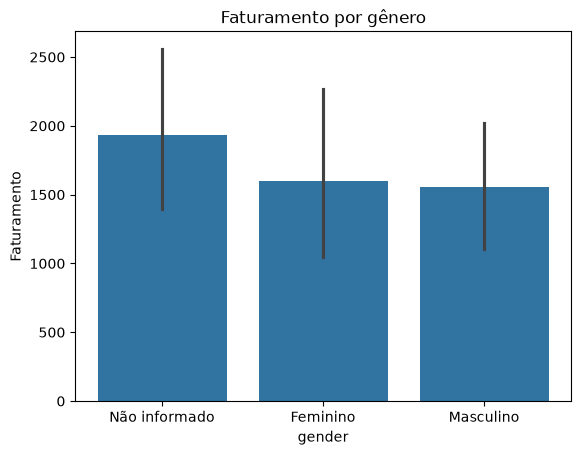

In [91]:
sns.barplot(x='gender', y='total_value', data=df)
plt.title('Faturamento por gênero')
plt.ylabel('Faturamento')
plt.plot()

Essa foi apenas uma demonstração, os dados por gênero sozinhos são poucos úteis, ainda mais pelo grande desvio padrão observado no gráfico

Vamos agora anaizar por **região**

[]

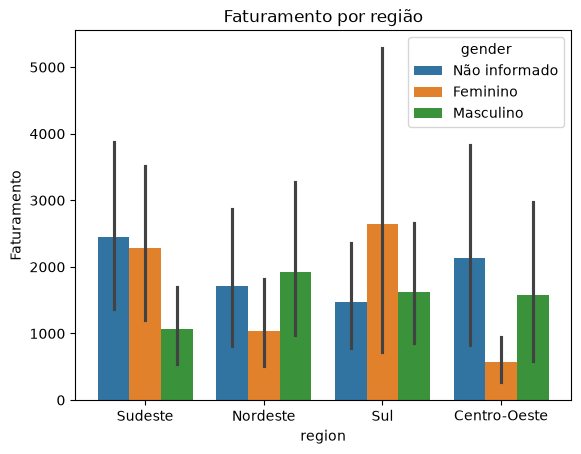

In [92]:
sns.barplot(x='region', y='total_value', hue='gender', data=df)
plt.title('Faturamento por região')
plt.ylabel('Faturamento')
plt.plot()

Agora nós temos dados bem interessantes sobre o faturamento de cada região, como o fato de na região Centro-Oeste o faturamento de clientes registrados como homens é quase o dobro do das mulheres, o que significa que é necessario campanhas para atrair o público feminino nessa região

[]

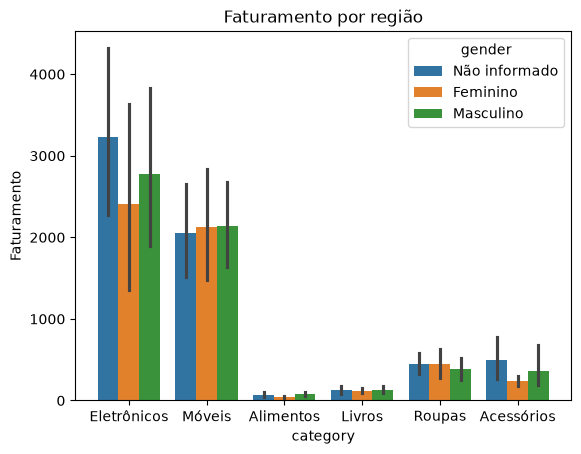

In [93]:
sns.barplot(x='category', y='total_value', hue='gender', data=df)
plt.title('Faturamento por região')
plt.ylabel('Faturamento')
plt.plot()

Aqui vemos de forma visual o que os números no tópico 2 mostraram, como o setor de **Eletrônicos** e **Móveis** se destacam bem mais que os demais

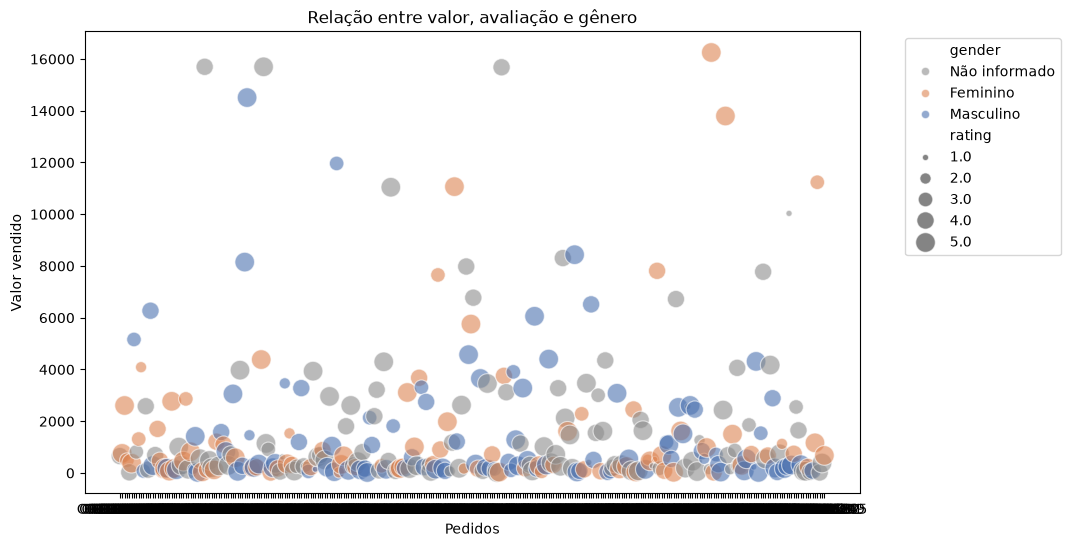

In [96]:
cores = {
    "Masculino": "#4C72B0",  # Azul
    "Feminino": "#DD8452",  # Laranja / Rosa
    "Não informado": "#8C8C8C",  # Cinza
}
plt.figure(figsize=(10, 6))
sns.scatterplot(x='order_id', y='total_value', alpha=0.6, size='rating', hue='gender', sizes=(20, 200), palette=cores, data=df)
plt.title('Relação entre valor, avaliação e gênero')
plt.ylabel('Valor vendido')
plt.xlabel('Pedidos')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

gráficos
- barras
faturamento por sexo
faturamento por regiao (sexo)
faturamento por categoria (sexo)
discoonto po produto
disconto por método de pagamento

- scatter
x=order_id, y=valor, tamanho por rating, cor por sexo

- linha
faturamento por mes

- histograma
produtos

- heatmap


